# Graphical Attention Network

### context:
University Karate Club: 
There was this Univeristy Karate club (total of 34 members) that have 2 leaders who do not like eachother. 

- Mr. Hi is the Karate instructor 
- John A. is the club president 

Both of them got into an arguement, which resulted in in the karate club members to split into 2 groups.

### Problem: 
Given only the friendship connections (the graph), can we predict which side each member choose when the club split?

### Load the dataset

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import networkx as nx

#load the karate club graph 
G = nx.karate_club_graph()

print("Number of nodes:", G.number_of_nodes()) # 34 members in the club
print("Number of edges:", G.number_of_edges()) # 78 friendships between members
print("Nodes:", G.nodes()) # List of members in the club
print("Edges:", G.edges()) # List of friendships (edges) between members

print()

print(G.nodes[0]) # To see the attributes of member 0

# To see the club affiliation of member 5
print(f"node: 5, club: {G.nodes[5]['club']}")

# To see the club affiliation of member 9
print(f"node: 9, club: {G.nodes[9]['club']}")

Number of nodes: 34
Number of edges: 78
Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)]

{'club': 'Mr. Hi'}
node: 5, club: Mr. Hi
node: 9, club: Officer


Making the Adjacency Matrix

In [63]:
# the built in Adjacecy matrix aparaently keep track of how strong the connection is between two nodes, so it is not binary. 
A = nx.adjacency_matrix(G).toarray() 
print(A.shape)
print(A)

print()

print("Binary adjacency matrix:")
# Make the adjacency matrix binary (1 if there is a connection, 0 if there is not)
A_binary = (A > 0).astype(float)
print(A_binary)


(34, 34)
[[0 4 5 ... 2 0 0]
 [4 0 6 ... 0 0 0]
 [5 6 0 ... 0 2 0]
 ...
 [2 0 0 ... 0 4 4]
 [0 0 2 ... 4 0 5]
 [0 0 0 ... 4 5 0]]

Binary adjacency matrix:
[[0. 1. 1. ... 1. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 1. 0. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 0. 1. 1.]
 [0. 0. 1. ... 1. 0. 1.]
 [0. 0. 0. ... 1. 1. 0.]]


Getting the features and ready for the graph dataset

In [64]:
num_nodes = G.number_of_nodes()
print(f"Number of nodes: {num_nodes}")

# unfortunately, the karate club graph does not have any node features, so we will use an identity matrix as a placeholder for the node features. Each node will be represented by a one-hot vector indicating its identity.
X = np.eye(num_nodes) # Identity matrix as node features 
print(X.shape)
print(X)

# assigning labels to the nodes based on their club affiliation
labels = np.array([0 if G.nodes[i]['club'] == 'Mr. Hi' else 1 for i in G.nodes()])

print()
# Print the labels for each node
print(labels)

Number of nodes: 34
(34, 34)
[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]

[0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


### Preparing the graph structure for attention

In [65]:
# Making self loops because in the GAT paper, they add self loops to the graph. This means that each node will also attend to itself when computing the attention scores. This allows the model to capture the importance of a node's own features in addition to the features of its neighbors.
# Editing the adjacency matrix to add self loops (i.e., set the diagonal to 1)
A_with_self_loops = A_binary + np.eye(num_nodes) # TLDR: Self loops makes it so that the nodes consider their own features when computing attention scores.
print(A_with_self_loops)

print()

# Edge list with self loops, so that if that we don't waste computing power on non-existent edges. This is important because in a GAT, we only compute attention scores for the edges that exist in the graph (including self loops), rather than for all possible pairs of nodes. This makes the model more efficient and focused on the relevant connections in the graph.
edges = np.array(np.where(A_with_self_loops > 0)).T 
print(f"Number of edges (with self-loops): {len(edges)}")
print("First 5 edges:", edges[:5])


# Convert everything to PyTorch tensors
X = torch.FloatTensor(X)
labels = torch.LongTensor(labels)
edges = torch.LongTensor(edges)
A_with_self_loops = torch.FloatTensor(A_with_self_loops)


[[1. 1. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [1. 1. 1. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 1. 1. 1.]
 [0. 0. 1. ... 1. 1. 1.]
 [0. 0. 0. ... 1. 1. 1.]]

Number of edges (with self-loops): 190
First 5 edges: [[0 0]
 [0 1]
 [0 2]
 [0 3]
 [0 4]]


### Building a single attention head

In [66]:
class GATHead(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # Head is just one attention mechanism, so we only have one set of parameters for the attention mechanism. If we had multiple heads, we would have multiple sets of parameters.
        self.W = nn.Parameter(torch.randn(in_features, out_features) * 0.1)
        self.a_self = nn.Parameter(torch.randn(out_features, 1) * 0.1)
        self.a_neighbor = nn.Parameter(torch.randn(out_features, 1) * 0.1)

    def forward(self, H, A_with_self_loops, edges):
        self_scores = H @ self.a_self
        neighbor_scores = H @ self.a_neighbor
        e = self_scores[edges[:, 0]] + neighbor_scores[edges[:, 1]]
        e = F.leaky_relu(e, 0.01)
        attention = torch.zeros_like(A_with_self_loops)
        for i in range(A_with_self_loops.shape[0]):
            neighbors = torch.where(A_with_self_loops[i] > 0)[0]
            edge_mask = edges[:, 0] == i
            scores = e[edge_mask].flatten()
            attention[i, neighbors] = torch.softmax(scores, dim=0)
        return attention

### Building a full GAT layer (multi-head)

In [67]:
class GAT(nn.Module):
    def __init__(self, in_features, hidden_features, num_classes, num_heads):
        super().__init__()
        # Layer 1
        self.heads1 = nn.ModuleList([
            GATHead(in_features, hidden_features) for _ in range(num_heads)
        ])
        self.W1 = nn.Parameter(torch.randn(in_features, hidden_features) * 0.1)
        
        # Layer 2
        self.heads2 = nn.ModuleList([
            GATHead(hidden_features * num_heads, num_classes) for _ in range(num_heads)
        ])
        self.W2 = nn.Parameter(torch.randn(hidden_features * num_heads, num_classes) * 0.1)

    def forward(self, X, A_with_self_loops, edges):
        # Layer 1: transform, attend, concatenate
        #tranfrom raw features to hidden features
        H1 = X @ self.W1
        attentions1 = [head(H1, A_with_self_loops, edges) for head in self.heads1]
        layer1_outs = [att @ H1 for att in attentions1]
        layer1_out = torch.cat(layer1_outs, dim=1)
        layer1_out = F.elu(layer1_out)
        
        # Layer 2: transform, attend, average
        H2 = layer1_out @ self.W2
        attentions2 = [head(H2, A_with_self_loops, edges) for head in self.heads2]
        layer2_outs = [att @ H2 for att in attentions2]
        layer2_out = torch.mean(torch.stack(layer2_outs), dim=0)
        
        return layer2_out

In [68]:
# Create model
model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

from torchinfo import summary
summary(model, input_data=(X, A_with_self_loops, edges))

GAT(
  (heads1): ModuleList(
    (0-2): 3 x GATHead()
  )
  (heads2): ModuleList(
    (0-2): 3 x GATHead()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
GAT                                      [34, 2]                   320
├─ModuleList: 1-1                        --                        --
│    └─GATHead: 2-1                      [34, 34]                  288
│    └─GATHead: 2-2                      [34, 34]                  288
│    └─GATHead: 2-3                      [34, 34]                  288
├─ModuleList: 1-2                        --                        --
│    └─GATHead: 2-4                      [34, 34]                  52
│    └─GATHead: 2-5                      [34, 34]                  52
│    └─GATHead: 2-6                      [34, 34]                  52
Total params: 1,340
Trainable params: 1,340
Non-trainable params: 0
Total mult-adds (M): 0
Input size (MB): 0.01
Forward/backward pass size (MB): 0.06
Params size (MB): 0.00
Estimated Total Size (MB): 0.07

### Train the Model

In [69]:

model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []  # track losses

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(X, A_with_self_loops, edges)
    loss = F.cross_entropy(output, labels)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())  # save each loss
    
    if epoch % 20 == 0:
        predictions = output.argmax(dim=1)
        accuracy = (predictions == labels).float().mean()
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

torch.save(model.state_dict(), "Weights_pretrained/gat_karate.pt")

Epoch 0, Loss: 0.6872, Accuracy: 0.7647
Epoch 20, Loss: 0.2111, Accuracy: 0.9706
Epoch 40, Loss: 0.0354, Accuracy: 1.0000
Epoch 60, Loss: 0.0064, Accuracy: 1.0000
Epoch 80, Loss: 0.0031, Accuracy: 1.0000
Epoch 100, Loss: 0.0021, Accuracy: 1.0000
Epoch 120, Loss: 0.0016, Accuracy: 1.0000
Epoch 140, Loss: 0.0012, Accuracy: 1.0000
Epoch 160, Loss: 0.0009, Accuracy: 1.0000
Epoch 180, Loss: 0.0008, Accuracy: 1.0000


### Visualize results

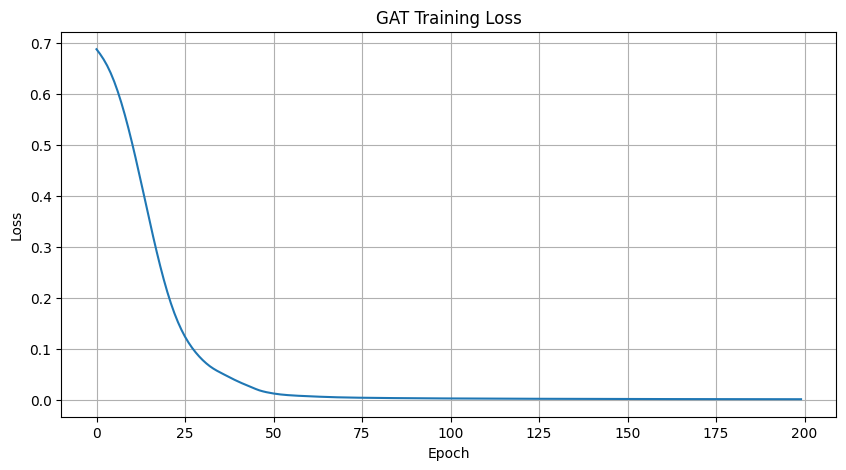

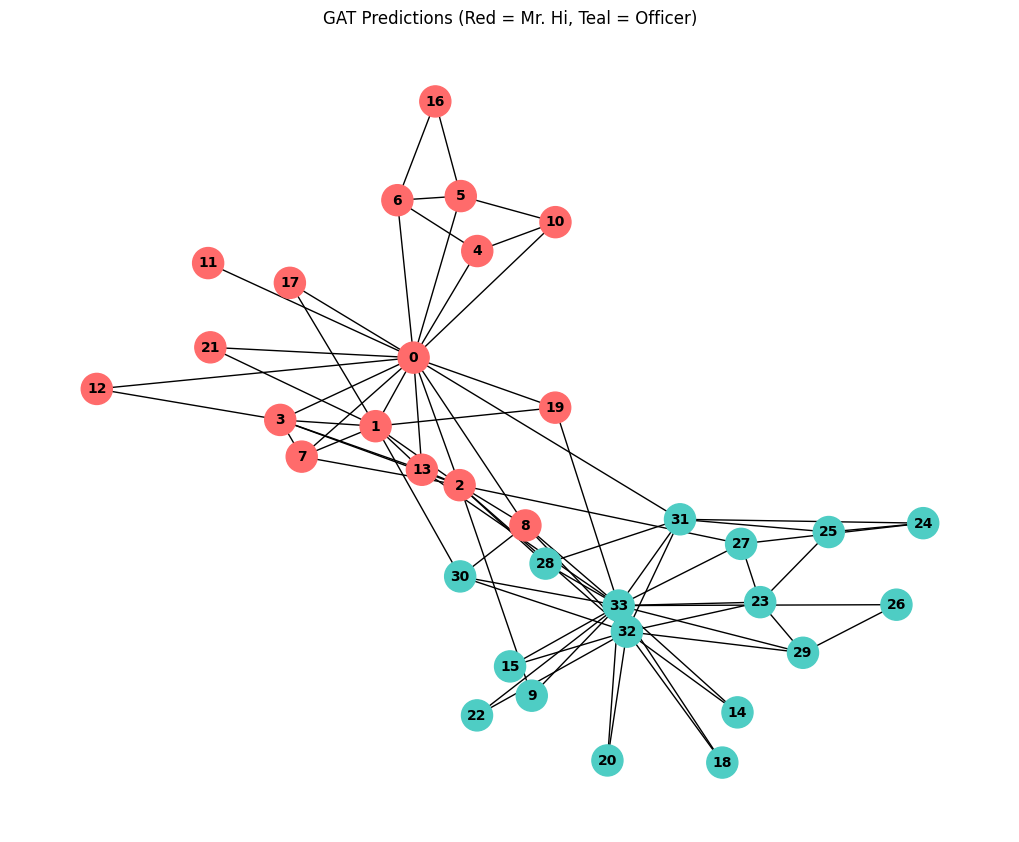

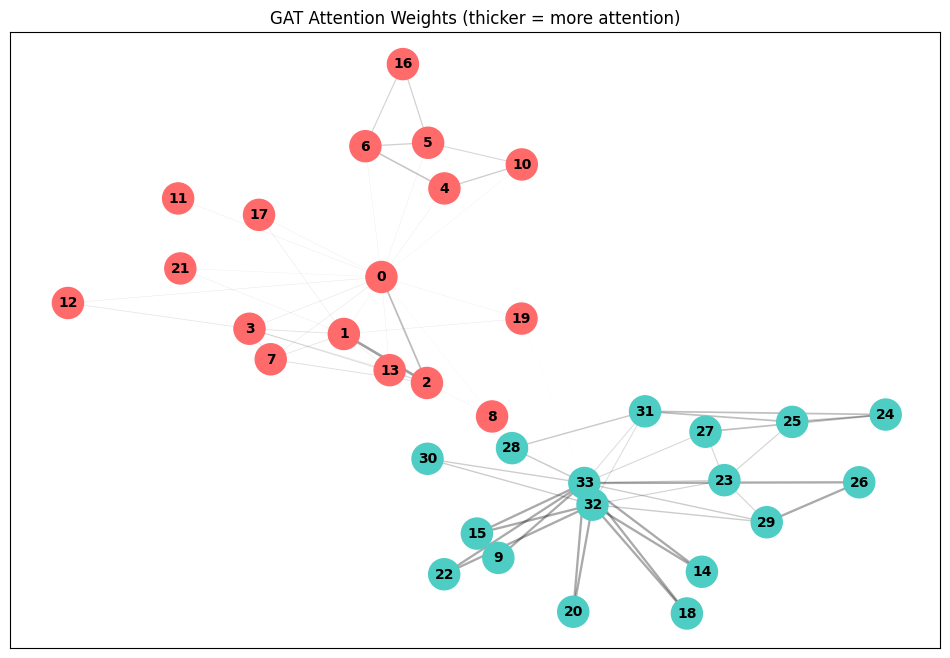

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAT Training Loss')
plt.grid(True)
plt.show()

model.eval()
with torch.no_grad():
    output = model(X, A_with_self_loops, edges)
    predictions = output.argmax(dim=1).numpy()

# Draw the graph with colored nodes
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
colors = ['#FF6B6B' if p == 0 else '#4ECDC4' for p in predictions]
nx.draw(G, pos, node_color=colors, with_labels=True, 
        node_size=500, font_size=10, font_weight='bold')
plt.title('GAT Predictions (Red = Mr. Hi, Teal = Officer)')
plt.show()

model.eval()
with torch.no_grad():
    H1 = X @ model.W1
    # Get attention from first head of layer 1
    attention = model.heads1[0](H1, A_with_self_loops, edges)
    attention = attention.numpy()

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
colors = ['#FF6B6B' if l == 0 else '#4ECDC4' for l in labels.numpy()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edges with width based on attention weights
for u, v in G.edges():
    weight = attention[u][v]
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], 
                           width=weight * 5, alpha=max(weight, 0.1))

plt.title('GAT Attention Weights (thicker = more attention)')
plt.show()

## Experiment: leave a node out 

the above training, I trained on 100% of the data. And beacause of that the model has overfitted the data. 

Since this is a smaller dataset. I can't really have a good split on the data. What if I tried to leave one node out. Like it would still be connected in the graph, But its label is hidden from the model during training. 

The Model can still see the node from the graph's structure, but it just doesn't know its label. 

In [71]:
correct = 0
wrong_nodes = []

# Loop through all the nodes, and have each node take turn to be hidden and see what the model predicts. See if the neighbor relationship help with the prediction
for test_node in range(num_nodes):
    model = GAT(in_features=34, hidden_features=8, num_classes=2, num_heads=3)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # set all nodes to be true 
    train_mask = torch.ones(num_nodes, dtype=torch.bool)
    # set the current node as false so that it is hidden during training
    train_mask[test_node] = False

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        output = model(X, A_with_self_loops, edges)
        # Only compute loss on the training nodes (excluding the test node)
        loss = F.cross_entropy(output[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        output = model(X, A_with_self_loops, edges)
        prediction = output[test_node].argmax().item()
        if prediction == labels[test_node].item():
            correct += 1

        else:
            wrong_nodes.append(test_node)

accuracy = correct / num_nodes
print(f"Leave-One-Out Accuracy: {accuracy:.4f} ({correct}/{num_nodes})")
print(f"Wrong nodes: {wrong_nodes}")



Leave-One-Out Accuracy: 0.9412 (32/34)
Wrong nodes: [8, 30]


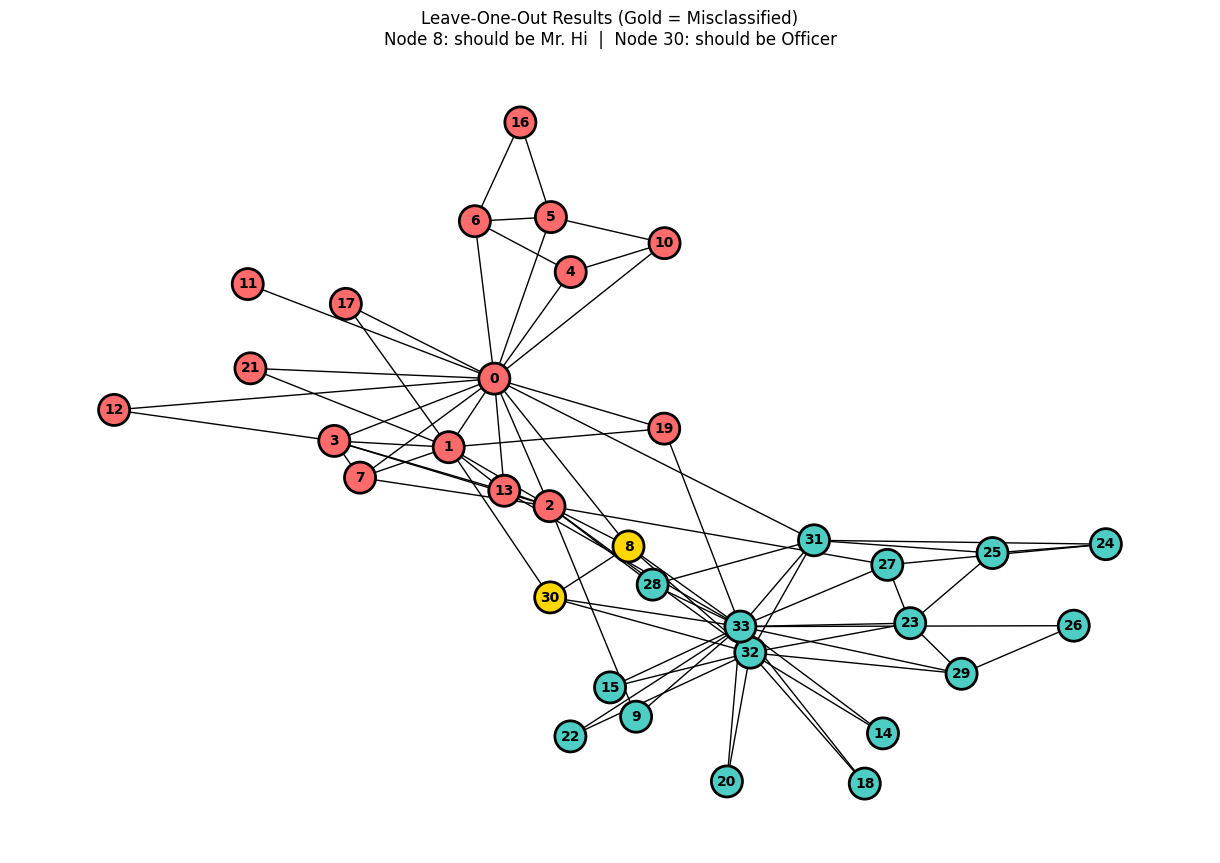

In [72]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# Color nodes: wrong ones get a special color
node_colors = []
for i in range(num_nodes):
    if i in wrong_nodes:
        node_colors.append('#FFD700')  # Gold for wrong predictions
    elif labels[i] == 0:
        node_colors.append('#FF6B6B')  # Red for Mr. Hi
    else:
        node_colors.append('#4ECDC4')  # Teal for Officer

nx.draw(G, pos, node_color=node_colors, with_labels=True,
        node_size=500, font_size=10, font_weight='bold',
        edgecolors='black', linewidths=2)

# Build description of wrong nodes
wrong_info = []
for node in wrong_nodes:
    true_label = "Mr. Hi" if labels[node] == 0 else "Officer"
    wrong_info.append(f"Node {node}: should be {true_label}")

plt.title('Leave-One-Out Results (Gold = Misclassified)\n' + '  |  '.join(wrong_info))
plt.show()

In [73]:
for node in wrong_nodes:
    true_label = "Mr. Hi" if labels[node] == 0 else "Officer"
    neighbors = list(G.neighbors(node))
    neighbor_labels = [("Mr. Hi" if labels[n] == 0 else "Officer") for n in neighbors]
    print(f"Node {node} (true: {true_label})")
    print(f"  Neighbors: {neighbors}")
    print(f"  Neighbor clubs: {neighbor_labels}")

Node 8 (true: Mr. Hi)
  Neighbors: [0, 2, 30, 32, 33]
  Neighbor clubs: ['Mr. Hi', 'Mr. Hi', 'Officer', 'Officer', 'Officer']
Node 30 (true: Officer)
  Neighbors: [1, 8, 32, 33]
  Neighbor clubs: ['Mr. Hi', 'Mr. Hi', 'Officer', 'Officer']


### Using Graphical Attention Network with CORA (LARGER DATABASE):

The Cora dataset is a citation network of 2,708 machine learning papers. Each paper (node) is connected to other papers it cites (edges), creating a graph of 5,429 links. Each paper belongs to one of 7 research categories: Case Based, Genetic Algorithms, Neural Networks, Probabilistic Methods, Reinforcement Learning, Rule Learning, and Theory.


The features: each paper has a 1,433-dimension feature vector representing which words appear in the paper. This is a big deal because unlike Karate Club where we had to use one-hot encoding, Cora has real features.

### Task: Predict which category each paper belongs to based on the citation graph and word features

In [74]:
! pip install torch_geometric

Defaulting to user installation because normal site-packages is not writeable


In [75]:
from torch_geometric.datasets import Planetoid

dataset = Planetoid(root='./data', name='Cora')
data = dataset[0]

print(f"Nodes: {data.num_nodes}")
print(f"Edges: {data.num_edges}")
print(f"Features per node: {data.num_node_features}")
print(f"Classes: {dataset.num_classes}")
print(f"Training nodes: {data.train_mask.sum().item()}")
print(f"Validation nodes: {data.val_mask.sum().item()}")
print(f"Test nodes: {data.test_mask.sum().item()}")

Nodes: 2708
Edges: 10556
Features per node: 1433
Classes: 7
Training nodes: 140
Validation nodes: 500
Test nodes: 1000


Visualize the Input data

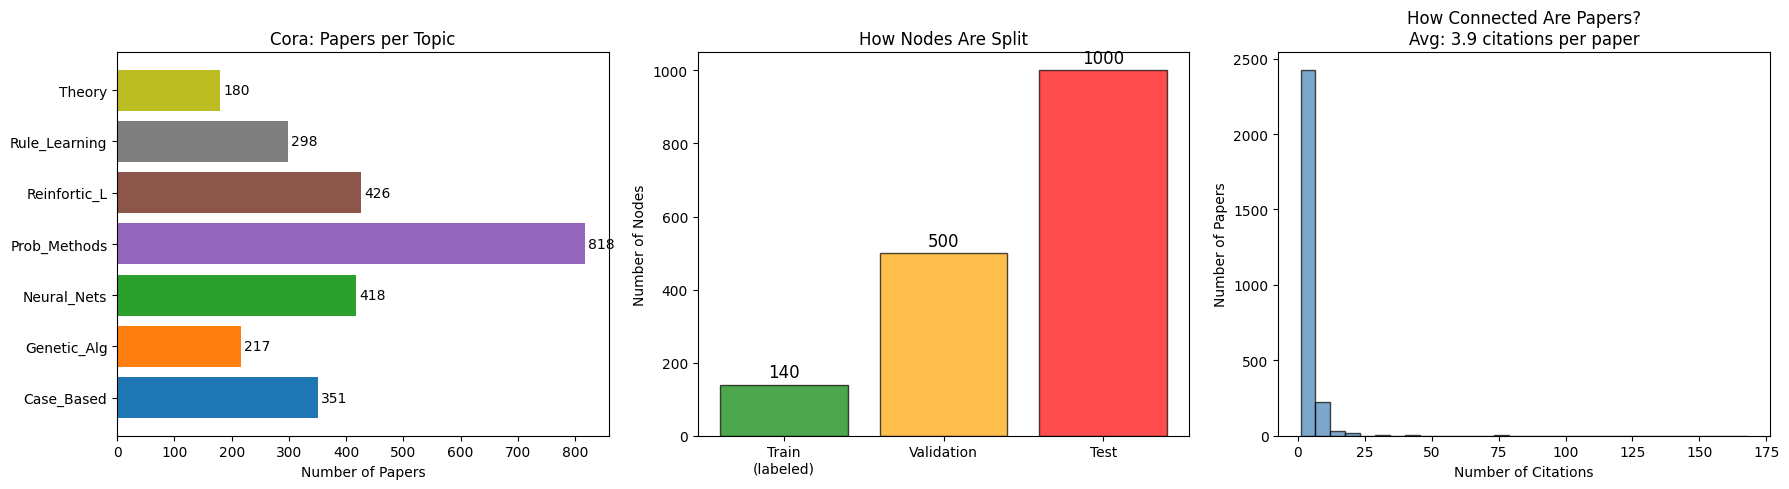

In [76]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
classes = data.y.numpy()
class_names = ['Case_Based', 'Genetic_Alg', 'Neural_Nets', 'Prob_Methods', 
               'Reinfortic_L', 'Rule_Learning', 'Theory']
counts = [np.sum(classes == i) for i in range(7)]

axes[0].barh(class_names, counts, color=plt.cm.tab10(np.arange(7)/7))
axes[0].set_xlabel('Number of Papers')
axes[0].set_title('Cora: Papers per Topic')
for i, v in enumerate(counts):
    axes[0].text(v + 5, i, str(v), va='center')

# 2. Node split (train/val/test)
split_counts = [data.train_mask.sum().item(), 
                data.val_mask.sum().item(), 
                data.test_mask.sum().item()]
split_labels = ['Train\n(labeled)', 'Validation', 'Test']
colors = ['green', 'orange', 'red']

axes[1].bar(split_labels, split_counts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Number of Nodes')
axes[1].set_title('How Nodes Are Split')
for i, v in enumerate(split_counts):
    axes[1].text(i, v + 20, str(v), ha='center', fontsize=12)

# 3. Degree distribution
edge_index = data.edge_index.numpy()
degrees = np.bincount(edge_index[0], minlength=data.num_nodes)

axes[2].hist(degrees, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Number of Citations')
axes[2].set_ylabel('Number of Papers')
axes[2].set_title(f'How Connected Are Papers?\nAvg: {degrees.mean():.1f} citations per paper')

plt.tight_layout()
plt.show()

Architecture for CORA GAT

In [77]:
from torch_geometric.nn import GATConv

class CoraGAT(nn.Module):
    def __init__(self, in_features, hidden_features, num_classes, num_heads, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        # use the built in GATConv layer from PyTorch Geometric, which handles the attention mechanism and message passing for us. We just need to specify the input/output dimensions and number of heads.
        self.gat1 = GATConv(in_features, hidden_features, heads=num_heads, dropout=dropout)
        # Find out its neighbor's neighbor's features, and then transform those features to the output dimension of the layer. The output dimension of the first layer is hidden_features * num_heads because we concatenate the outputs from all heads.
        self.gat2 = GATConv(hidden_features * num_heads, num_classes, heads=1, dropout=dropout)
    
    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x

Training Loop

In [78]:
model = CoraGAT(in_features=1433, hidden_features=8, num_classes=7, num_heads=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

In [79]:
losses = []
val_accs = []
train_accs = []

for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(data.x, data.edge_index)
    loss = F.cross_entropy(output[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    
    model.eval()
    with torch.no_grad():
        output = model(data.x, data.edge_index)
        # Grab only the training nodes prediction and pick which ever class has the highest score as the predicted class
        train_pred = output[data.train_mask].argmax(dim=1)
        # Grab only the validation nodes prediction and pick which ever class has the highest score as the predicted class
        val_pred = output[data.val_mask].argmax(dim=1)
        # Calculate the training accuracy by comparing the predicted classes to the true labels for the training nodes, and take the mean to get the overall accuracy
        train_accs.append((train_pred == data.y[data.train_mask]).float().mean().item())
        val_accs.append((val_pred == data.y[data.val_mask]).float().mean().item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}, Train Acc: {train_accs[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")
    
torch.save(model.state_dict(), 'Weights_pretrained/gat_cora_node.pt')

Epoch 0, Loss: 1.9447, Train Acc: 0.5857, Val Acc: 0.5340
Epoch 20, Loss: 0.8868, Train Acc: 0.9643, Val Acc: 0.8040
Epoch 40, Loss: 0.6676, Train Acc: 0.9929, Val Acc: 0.7980
Epoch 60, Loss: 0.6040, Train Acc: 0.9929, Val Acc: 0.7900
Epoch 80, Loss: 0.5361, Train Acc: 1.0000, Val Acc: 0.7880
Epoch 100, Loss: 0.4304, Train Acc: 1.0000, Val Acc: 0.7940
Epoch 120, Loss: 0.4020, Train Acc: 1.0000, Val Acc: 0.7880
Epoch 140, Loss: 0.5313, Train Acc: 1.0000, Val Acc: 0.7900
Epoch 160, Loss: 0.3647, Train Acc: 1.0000, Val Acc: 0.7580
Epoch 180, Loss: 0.4804, Train Acc: 1.0000, Val Acc: 0.7800


Evaluate

In [80]:
model.eval()
with torch.no_grad():
    output = model(data.x, data.edge_index)
    test_pred = output[data.test_mask].argmax(dim=1)
    test_acc = (test_pred == data.y[data.test_mask]).float().mean()
    print(f"Test Accuracy: {test_acc:.4f} ({test_pred.eq(data.y[data.test_mask]).sum().item()}/{data.test_mask.sum().item()})")

Test Accuracy: 0.7830 (783/1000)


T-SNE for 2D visualization of the different classes

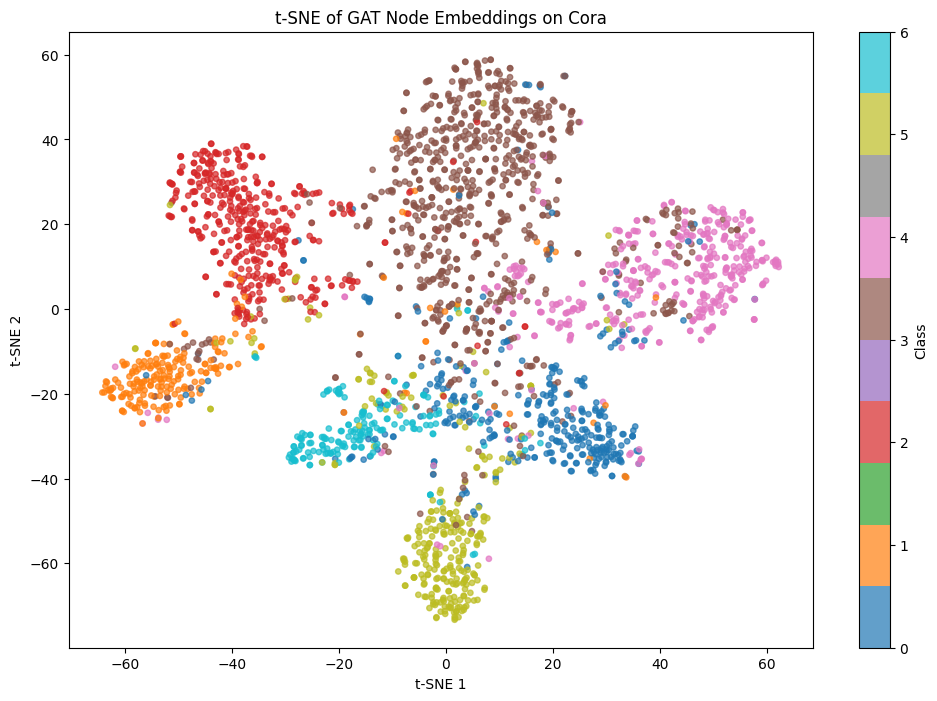

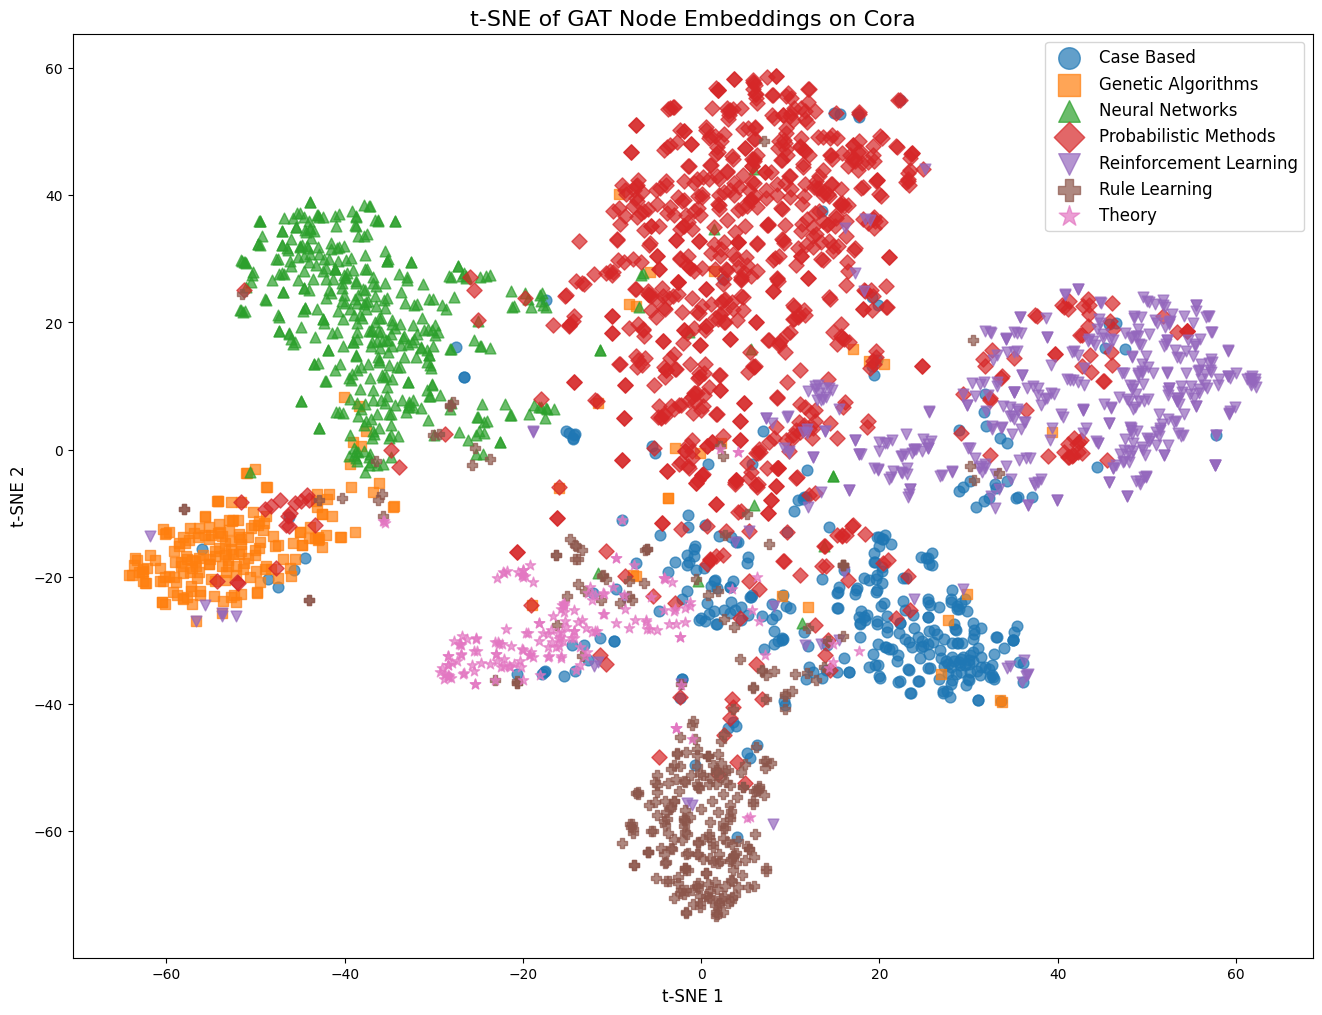

In [81]:
from sklearn.manifold import TSNE

model.eval()
with torch.no_grad():
    # Get embeddings from layer 1 (before final classification)
    x = F.dropout(data.x, p=0.6, training=False)
    embeddings = model.gat1(x, data.edge_index)
    embeddings = F.elu(embeddings)
    embeddings = embeddings.numpy()

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                      c=data.y.numpy(), cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Class')
plt.title('t-SNE of GAT Node Embeddings on Cora')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

class_names = ['Case Based', 'Genetic Algorithms', 'Neural Networks', 
               'Probabilistic Methods', 'Reinforcement Learning', 
               'Rule Learning', 'Theory']
markers = ['o', 's', '^', 'D', 'v', 'P', '*']

plt.figure(figsize=(16, 12))
for i, name in enumerate(class_names):
    mask = data.y.numpy() == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                s=60, alpha=0.7, label=name, marker=markers[i])

plt.legend(markerscale=2, fontsize=12)
plt.title('t-SNE of GAT Node Embeddings on Cora', fontsize=16)
plt.xlabel('t-SNE 1', fontsize=12)
plt.ylabel('t-SNE 2', fontsize=12)
plt.show()

Training accuracy and Validation accuaracy flatten

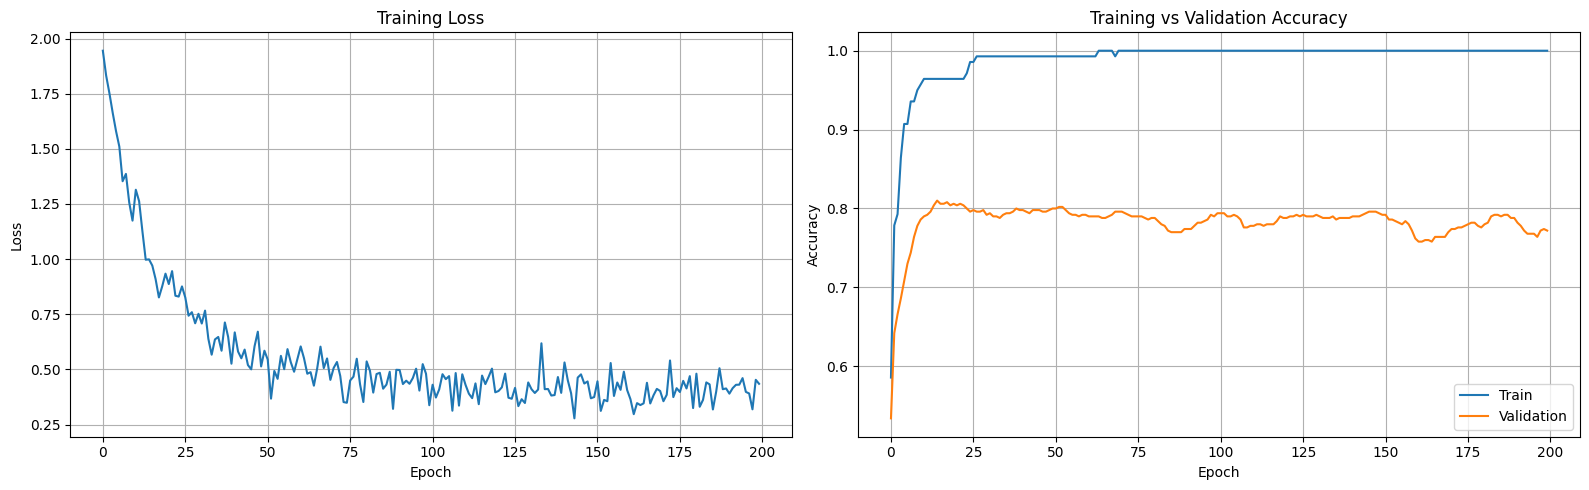

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Training loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# 2. Training vs Validation accuracy
axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Confusion Matrix

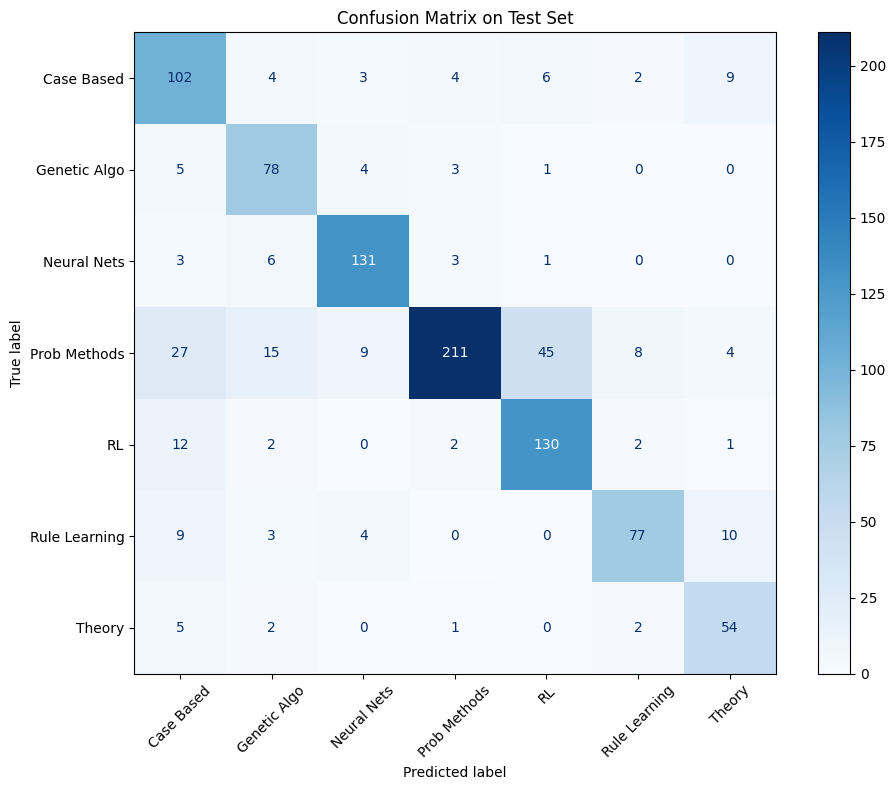

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    output = model(data.x, data.edge_index)
    test_pred = output[data.test_mask].argmax(dim=1).numpy()
    test_true = data.y[data.test_mask].numpy()

class_names = ['Case Based', 'Genetic Algo', 'Neural Nets', 
               'Prob Methods', 'RL', 'Rule Learning', 'Theory']

cm = confusion_matrix(test_true, test_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.show()

Per class accuracy

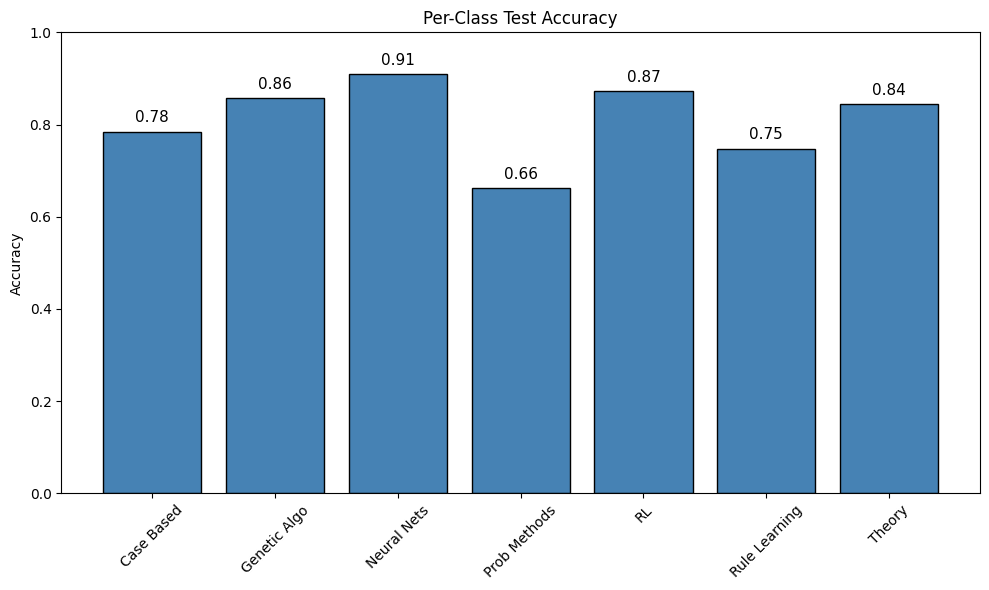

In [84]:
class_names = ['Case Based', 'Genetic Algo', 'Neural Nets', 
               'Prob Methods', 'RL', 'Rule Learning', 'Theory']

per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, per_class_acc, color='steelblue', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Per-Class Test Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1.0)

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{acc:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Link Prediction
### Problem statement 

We have the Cora citation network: 2,708 papers connected by citation links. We can see all the papers and their features, but what if some citations are missing?

Goal: Given two papers, predict whether a citation link should exist between them.


load the data

In [85]:
import torch
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T

# Load Cora and split edges into train/val/test
dataset = Planetoid(root='data/', name='Cora',
                    transform=T.RandomLinkSplit(
                        num_val=0.1,
                        num_test=0.2,
                        is_undirected=True,
                        add_negative_train_samples=True # This means that during training, we will also include some negative samples (non-existent edges) to help the model learn to distinguish between real and fake connections.
                        # Binary classifcation problem where the model has to predict whether an edge exists or not, rather than predicting node classes.
                    ))

train_data, val_data, test_data = dataset[0]

print(f"Total nodes: {train_data.num_nodes}")
print(f"Node features: {train_data.num_features}")
print(f"Train edges: {train_data.edge_label.sum().int().item()} positive")
print(f"Val edges:   {val_data.edge_label.sum().int().item()} positive")
print(f"Test edges:  {test_data.edge_label.sum().int().item()} positive")

Total nodes: 2708
Node features: 1433
Train edges: 3696 positive
Val edges:   527 positive
Test edges:  1055 positive


Visualize the Input data

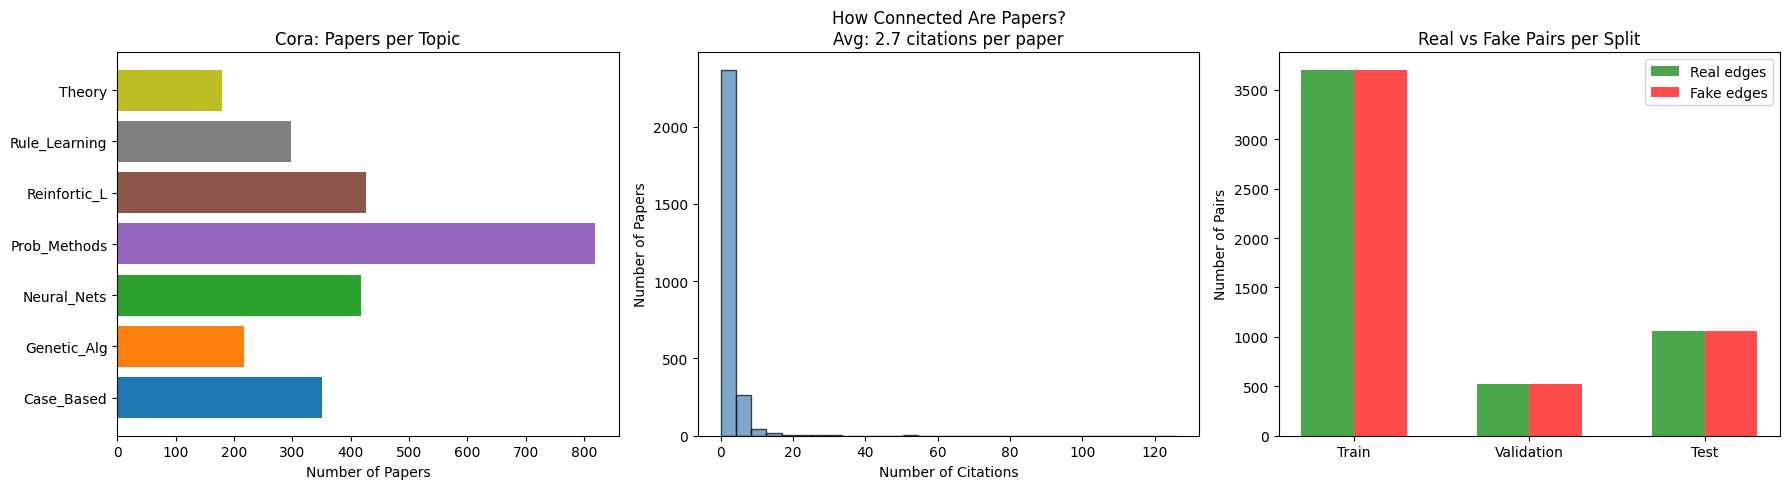

In [86]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
classes = train_data.y.numpy()
class_names = ['Case_Based', 'Genetic_Alg', 'Neural_Nets', 'Prob_Methods', 
               'Reinfortic_L', 'Rule_Learning', 'Theory']
counts = [np.sum(classes == i) for i in range(7)]

axes[0].barh(class_names, counts, color=plt.cm.tab10(np.arange(7)/7))
axes[0].set_xlabel('Number of Papers')
axes[0].set_title('Cora: Papers per Topic')

# 2. Degree distribution (how connected each paper is)
edge_index = train_data.edge_index.numpy()
degrees = np.bincount(edge_index[0], minlength=train_data.num_nodes)

axes[1].hist(degrees, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Citations')
axes[1].set_ylabel('Number of Papers')
axes[1].set_title(f'How Connected Are Papers?\nAvg: {degrees.mean():.1f} citations per paper')

# 3. Edge split breakdown (positive + negative)
categories = ['Train', 'Validation', 'Test']
positives = [train_data.edge_label.sum().int().item(),
             val_data.edge_label.sum().int().item(),
             test_data.edge_label.sum().int().item()]
negatives = [len(train_data.edge_label) - positives[0],
             len(val_data.edge_label) - positives[1],
             len(test_data.edge_label) - positives[2]]

x = np.arange(3)
axes[2].bar(x - 0.15, positives, 0.3, label='Real edges', color='green', alpha=0.7)
axes[2].bar(x + 0.15, negatives, 0.3, label='Fake edges', color='red', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories)
axes[2].set_ylabel('Number of Pairs')
axes[2].set_title('Real vs Fake Pairs per Split')
axes[2].legend()

plt.tight_layout()
plt.show()

Building the GAT Encoder

In [87]:
import torch.nn as nn
from torch_geometric.nn import GATConv

class GATEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # Each node learn about its neighbors and itself to compute attention scores.
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads)
        # Now each node has knowledge about their neighbors 's neighboers.
        self.gat2 = GATConv(hidden_channels * heads, out_channels, heads=1)
    
    def forward(self, x, edge_index):
        x = self.dropout(x)
        x = self.gat1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)

        return x

# Initialize
model = GATEncoder(
    in_channels=train_data.num_features,  # 1433
    hidden_channels=32,
    out_channels=64,  # embedding size
    dropout=0.5
)

print(model)

GATEncoder(
  (dropout): Dropout(p=0.5, inplace=False)
  (gat1): GATConv(1433, 32, heads=4)
  (gat2): GATConv(128, 64, heads=1)
)


Score node pairs

In [88]:
def predict_link(model, data):
    # Get embeddings for ALL nodes
    z = model(data.x, data.edge_index)
    
    # Grab the two nodes in each pair
    src = data.edge_label_index[0]  # grabs the first row in each pair 
    dst = data.edge_label_index[1]  # grabs the second row in each pair
    
    # Dot product: how similar are their embeddings? Compare souce to destination
    scores = (z[src] * z[dst]).sum(dim=1) # higher the score, more likely there is an edge between them
    
    # Squeeze into 0-1 range
    return torch.sigmoid(scores)

Train the model

In [89]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCELoss()  # Binary Cross Entropy

# Train 100 epochs
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    pred = predict_link(model, train_data)
    loss = loss_fn(pred, train_data.edge_label.float())
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f}")
torch.save(model.state_dict(), 'Weights_pretrained/gat_cora_link.pt')

Epoch  20 | Loss: 0.4952
Epoch  40 | Loss: 0.4080
Epoch  60 | Loss: 0.3596
Epoch  80 | Loss: 0.3213
Epoch 100 | Loss: 0.2902


Evaluate on test data

In [90]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate(data):
    model.eval()
    with torch.no_grad():
        pred = predict_link(model, data)
    
    pred_labels = (pred > 0.5).float()
    
    acc = accuracy_score(data.edge_label, pred_labels)
    auc = roc_auc_score(data.edge_label, pred)
    
    return acc, auc

# Evaluate
val_acc, val_auc = evaluate(val_data)
test_acc, test_auc = evaluate(test_data)
print(f"\nVal  Accuracy: {val_acc:.4f} | AUC: {val_auc:.4f}")
print(f"Test Accuracy: {test_acc:.4f} | AUC: {test_auc:.4f}")


Val  Accuracy: 0.7211 | AUC: 0.8730
Test Accuracy: 0.7251 | AUC: 0.8831


Visualize 

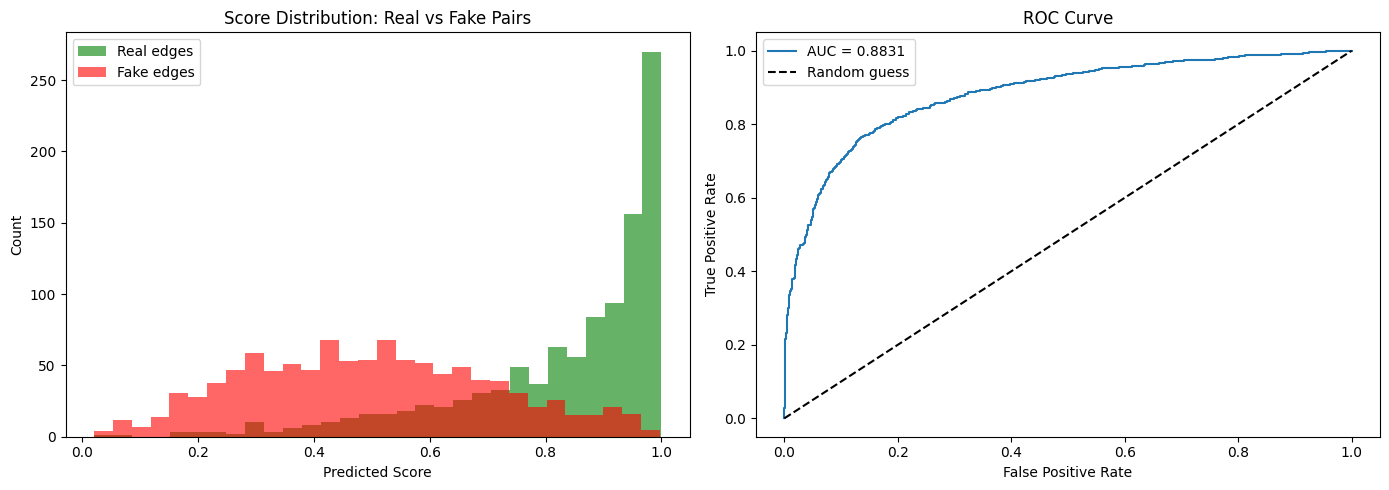

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

model.eval()
with torch.no_grad():
    pred = predict_link(model, test_data)

scores = pred.numpy()
labels = test_data.edge_label.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Score Distribution: do positive and negative pairs get different scores?
axes[0].hist(scores[labels == 1], bins=30, alpha=0.6, label='Real edges', color='green')
axes[0].hist(scores[labels == 0], bins=30, alpha=0.6, label='Fake edges', color='red')
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution: Real vs Fake Pairs')
axes[0].legend()

# 2. ROC Curve: how well does the model separate real from fake?
fpr, tpr, _ = roc_curve(labels, scores)
axes[1].plot(fpr, tpr, label=f'AUC = {test_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Problem Statement

We have 188 molecules, each represented as a small graph where atoms are nodes and chemical bonds are edges. Each molecule is labeled as mutagenic (can damage DNA) or not mutagenic (safe).
## Goal: 

Given a molecule's structure (how its atoms are connected), predict whether the entire molecule is mutagenic or not.

## Why this is a new challenge:

In node classification, we predicted labels for individual nodes inside one graph. In link prediction, we predicted missing edges inside one graph. Now we have many separate graphs, and each one needs a single yes/no prediction. The model has to look at the whole molecule and make one judgment call.

In [92]:
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader

# Load MUTAG
dataset = TUDataset(root='data/', name='MUTAG')

print(f"Total molecules: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Node features per atom: {dataset.num_node_features}")

# Look at one molecule
mol = dataset[0]
print(f"\nFirst molecule:")
print(f"  Atoms (nodes): {mol.num_nodes}")
print(f"  Bonds (edges): {mol.num_edges}")
print(f"  Label: {mol.y.item()} ({'mutagenic' if mol.y.item() == 1 else 'not mutagenic'})")

# Split into train/test
torch.manual_seed(42)
dataset = dataset.shuffle()
train_set = dataset[:150]
test_set = dataset[150:]

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32)

print(f"\nTrain molecules: {len(train_set)}")
print(f"Test molecules: {len(test_set)}")

Total molecules: 188
Number of classes: 2
Node features per atom: 7

First molecule:
  Atoms (nodes): 17
  Bonds (edges): 38
  Label: 1 (mutagenic)

Train molecules: 150
Test molecules: 38


visualize the input data

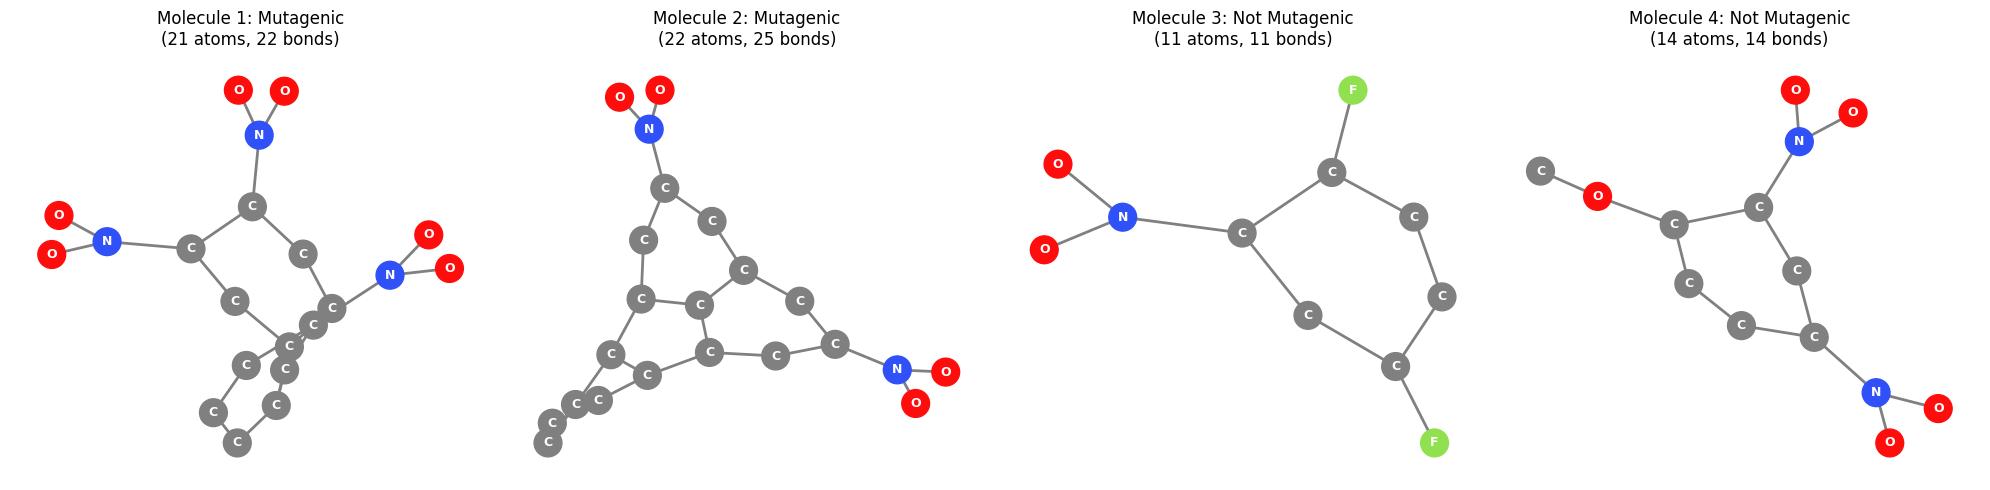

In [93]:
import networkx as nx
import matplotlib.pyplot as plt

# Atom type labels (MUTAG uses one-hot encoding for 7 atom types)
atom_labels = ['C', 'N', 'O', 'F', 'I', 'Cl', 'Br']

def get_atom_type(node_features):
    return atom_labels[node_features.argmax().item()]

# Pick 4 molecules (2 mutagenic, 2 not)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

count_mut = 0
count_not = 0
samples = []

for data in dataset:
    if data.y.item() == 1 and count_mut < 2:
        samples.append(data)
        count_mut += 1
    elif data.y.item() == 0 and count_not < 2:
        samples.append(data)
        count_not += 1
    if count_mut == 2 and count_not == 2:
        break

for idx, mol in enumerate(samples):
    # Convert to NetworkX graph
    G = nx.Graph()
    for i in range(mol.num_nodes):
        G.add_node(i, label=get_atom_type(mol.x[i]))
    
    edges = mol.edge_index.t().tolist()
    for src, dst in edges:
        if src < dst:
            G.add_edge(src, dst)
    
    # Color atoms by type
    color_map = {'C': '#808080', 'N': '#3050F8', 'O': '#FF0D0D', 
                 'F': '#90E050', 'I': '#940094', 'Cl': '#1FF01F', 'Br': '#A62929'}
    colors = [color_map[G.nodes[n]['label']] for n in G.nodes]
    labels = {n: G.nodes[n]['label'] for n in G.nodes}
    
    label_text = "Mutagenic" if mol.y.item() == 1 else "Not Mutagenic"
    
    axes[idx].set_title(f"Molecule {idx+1}: {label_text}\n({mol.num_nodes} atoms, {mol.num_edges//2} bonds)")
    nx.draw(G, ax=axes[idx], with_labels=True, labels=labels,
            node_color=colors, node_size=400, font_size=9,
            font_color='white', font_weight='bold',
            edge_color='gray', width=2)

plt.tight_layout()
plt.show()

Makinging a GATGraphClassifier

In [94]:
from torch_geometric.nn import GATConv, global_mean_pool

class GATGraphClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, dropout=dropout)
        self.classifier = nn.Linear(hidden_channels, num_classes)
    
    def forward(self, x, edge_index, batch):
        x = self.gat1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.gat2(x, edge_index)
        x = global_mean_pool(x, batch)
        x = self.classifier(x)
        return x

model = GATGraphClassifier(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    num_classes=2,
    dropout=0.3
)

print(model)

GATGraphClassifier(
  (dropout): Dropout(p=0.3, inplace=False)
  (gat1): GATConv(7, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)


Train the Model

In [95]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Count how many of each class
labels_list = [data.y.item() for data in train_set]
num_not_mutagenic = labels_list.count(0)
num_mutagenic = labels_list.count(1)

print(f"Train set: {num_not_mutagenic} not mutagenic, {num_mutagenic} mutagenic")

# Higher weight for the underrepresented class
weight = torch.tensor([num_mutagenic / num_not_mutagenic, 1.0])
print(f"Class weights: {weight}")

loss_fn = nn.CrossEntropyLoss(weight=weight)

train_losses = []
train_accs = []
test_accs = []

def train():
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = loss_fn(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def test(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.y.size(0)
    return correct / total

for epoch in range(1, 201):
    loss = train()
    train_losses.append(loss)
    if epoch % 10 == 0:
        tr_acc = test(train_loader)
        te_acc = test(test_loader)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train: {tr_acc:.4f} | Test: {te_acc:.4f}")

torch.save(model.state_dict(), 'Weights_pretrained/gat_mutag_graph.pt')

Train set: 46 not mutagenic, 104 mutagenic
Class weights: tensor([2.2609, 1.0000])
Epoch  10 | Loss: 0.6428 | Train: 0.7133 | Test: 0.6579
Epoch  20 | Loss: 0.5714 | Train: 0.7267 | Test: 0.6579
Epoch  30 | Loss: 0.5520 | Train: 0.7533 | Test: 0.6579
Epoch  40 | Loss: 0.5520 | Train: 0.7533 | Test: 0.6579
Epoch  50 | Loss: 0.5699 | Train: 0.7467 | Test: 0.6579
Epoch  60 | Loss: 0.5367 | Train: 0.7600 | Test: 0.6842
Epoch  70 | Loss: 0.5546 | Train: 0.7867 | Test: 0.7105
Epoch  80 | Loss: 0.5418 | Train: 0.7933 | Test: 0.6842
Epoch  90 | Loss: 0.5376 | Train: 0.7867 | Test: 0.7105
Epoch 100 | Loss: 0.5190 | Train: 0.7933 | Test: 0.7105
Epoch 110 | Loss: 0.5039 | Train: 0.7867 | Test: 0.6842
Epoch 120 | Loss: 0.5583 | Train: 0.7867 | Test: 0.6842
Epoch 130 | Loss: 0.5323 | Train: 0.7933 | Test: 0.7105
Epoch 140 | Loss: 0.5359 | Train: 0.7867 | Test: 0.7105
Epoch 150 | Loss: 0.5291 | Train: 0.7933 | Test: 0.7105
Epoch 160 | Loss: 0.5350 | Train: 0.7933 | Test: 0.6842
Epoch 170 | Loss: 0.5

Visualize

Test: 27/38 correct (71.1%)


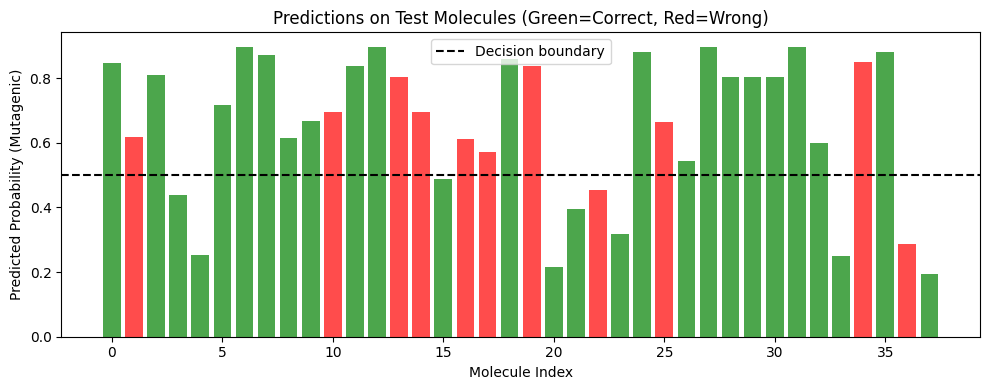

In [96]:
import matplotlib.pyplot as plt

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.softmax(out, dim=1)[:, 1]
        pred = out.argmax(dim=1)
        all_preds.extend(pred.tolist())
        all_labels.extend(batch.y.tolist())
        all_probs.extend(probs.tolist())

correct = sum(p == l for p, l in zip(all_preds, all_labels))
print(f"Test: {correct}/{len(all_labels)} correct ({correct/len(all_labels)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if p == l else 'red' for p, l in zip(all_preds, all_labels)]
ax.bar(range(len(all_probs)), all_probs, color=colors, alpha=0.7)
ax.axhline(y=0.5, color='black', linestyle='--', label='Decision boundary')
ax.set_xlabel('Molecule Index')
ax.set_ylabel('Predicted Probability (Mutagenic)')
ax.set_title('Predictions on Test Molecules (Green=Correct, Red=Wrong)')
ax.legend()
plt.tight_layout()
plt.show()

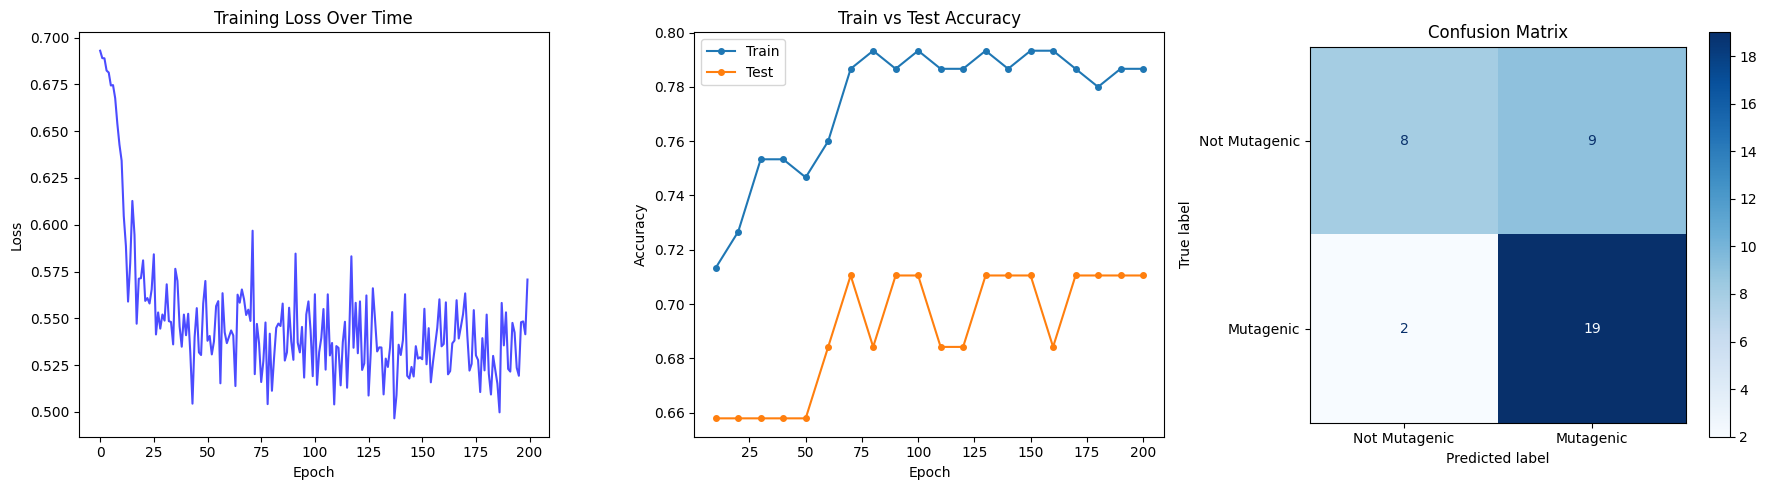

In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index, batch.batch)
        probs = torch.softmax(out, dim=1)[:, 1]
        pred = out.argmax(dim=1)
        all_preds.extend(pred.tolist())
        all_labels.extend(batch.y.tolist())
        all_probs.extend(probs.tolist())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training curve
axes[0].plot(train_losses, color='blue', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Over Time')

# 2. Train vs Test accuracy
epochs = list(range(10, 201, 10))
axes[1].plot(epochs, train_accs, label='Train', marker='o', markersize=4)
axes[1].plot(epochs, test_accs, label='Test', marker='o', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Test Accuracy')
axes[1].legend()

# 3. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Mutagenic', 'Mutagenic'])
disp.plot(ax=axes[2], cmap='Blues')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()

# References:
1) https://networkx.org/documentation/stable/tutorial.html
2) https://networkx.org/documentation/stable/reference/generated/networkx.generators.social.karate_club_graph.html
3) https://networkx.org/documentation/stable/reference/generated/networkx.linalg.graphmatrix.adjacency_matrix.html
4) https://numpy.org/devdocs/reference/generated/numpy.where.html
5) https://docs.pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html
6) https://docs.pytorch.org/docs/stable/generated/torch.nn.ModuleList.html
7) https://docs.pytorch.org/docs/stable/generated/torch.numel.html
8) https://pytorch-geometric.readthedocs.io/en/2.5.0/generated/torch_geometric.datasets.Planetoid.html
9) https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.conv.GATConv.html
10) https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.datasets.TUDataset.html
11) https://pytorch-geometric.readthedocs.io/en/2.7.0/modules/loader.html#torch_geometric.loader.DataLoader
12) https://www.youtube.com/watch?v=aFnHYEv71U4